<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/EWMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
data = [10, 20, 30, 40, 50]

beta = 0.9
v = 0

for x in data:
    v = beta * v + (1 - beta) * x
    print(v)

0.9999999999999998
2.8999999999999995
5.6099999999999985
9.048999999999998
13.144099999999998


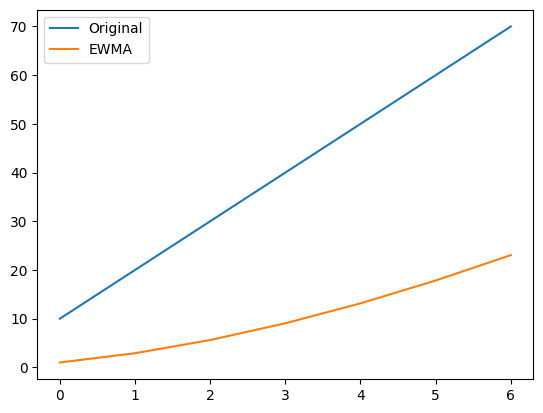

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = [10, 20, 30, 40, 50, 60, 70]

beta = 0.9
v = 0

ewma = []

for x in data:
    v = beta * v + (1 - beta) * x
    ewma.append(v)

plt.plot(data, label='Original')
plt.plot(ewma, label='EWMA')

plt.legend()
plt.show()

#Another Program

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

In [5]:
 #STEP 1: LOAD DATASET
# ---------------------------------------------------

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
# STEP 2: BUILD MODEL
# ---------------------------------------------------

model = Sequential([

    # Convert 28x28 image into vector
    Flatten(input_shape=(28, 28)),

    # Hidden Layer
    Dense(128, activation='relu'),

    # Hidden Layer
    Dense(64, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# ---------------------------------------------------
# STEP 3: COMPILE MODEL
# ---------------------------------------------------

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
# STEP 4: CUSTOM CALLBACK FOR EWMA
# ---------------------------------------------------

class EWMAMonitor(tf.keras.callbacks.Callback):

    def __init__(self, beta=0.9):
        super().__init__()

        # EWMA smoothing parameter
        self.beta = beta

        # Store original values
        self.raw_losses = []
        self.raw_accuracies = []

        # Store smoothed values
        self.ewma_losses = []
        self.ewma_accuracies = []

        # Initialize moving averages
        self.v_loss = 0
        self.v_acc = 0

    def on_epoch_end(self, epoch, logs=None):

        # Get current values
        loss = logs['loss']
        acc = logs['accuracy']

        # Save raw values
        self.raw_losses.append(loss)
        self.raw_accuracies.append(acc)

        # ---------------------------------------------------
        # EWMA FORMULA
        # Vt = beta * Vt-1 + (1-beta) * current_value
        # ---------------------------------------------------

        self.v_loss = self.beta * self.v_loss + (1 - self.beta) * loss
        self.v_acc = self.beta * self.v_acc + (1 - self.beta) * acc

        # ---------------------------------------------------
        # BIAS CORRECTION
        # V_corrected = V / (1 - beta^t)
        # ---------------------------------------------------

        corrected_loss = self.v_loss / (1 - self.beta ** (epoch + 1))
        corrected_acc = self.v_acc / (1 - self.beta ** (epoch + 1))

        # Store corrected values
        self.ewma_losses.append(corrected_loss)
        self.ewma_accuracies.append(corrected_acc)

        # Print results
        print(f"\nEpoch {epoch+1}")
        print(f"Raw Loss      : {loss:.4f}")
        print(f"Smoothed Loss : {corrected_loss:.4f}")

        print(f"Raw Accuracy      : {acc:.4f}")
        print(f"Smoothed Accuracy : {corrected_acc:.4f}")

# ---------------------------------------------------
# STEP 5: CREATE EWMA CALLBACK
# ---------------------------------------------------

ewma_callback = EWMAMonitor(beta=0.9)

# ---------------------------------------------------
# STEP 6: TRAIN MODEL
# ---------------------------------------------------

history = model.fit(

    x_train,
    y_train,

    validation_data=(x_test, y_test),

    epochs=10,
    batch_size=128,

    callbacks=[ewma_callback]
)


Epoch 1/10
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8351 - loss: 0.6093
Epoch 1
Raw Loss      : 0.3292
Smoothed Loss : 0.3292
Raw Accuracy      : 0.9090
Smoothed Accuracy : 0.9090
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9090 - loss: 0.3292 - val_accuracy: 0.9460 - val_loss: 0.1797
Epoch 2/10
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9572 - loss: 0.1494
Epoch 2
Raw Loss      : 0.1352
Smoothed Loss : 0.2271
Raw Accuracy      : 0.9607
Smoothed Accuracy : 0.9362
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9607 - loss: 0.1352 - val_accuracy: 0.9677 - val_loss: 0.1107
Epoch 3/10
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9705 - loss: 0.0967
Epoch 3
Raw Loss      : 0.0941
Smoothed Loss : 0.1780
Raw Accuracy      : 0.9720
Smoothed Accuracy : 0.9494
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9720 - loss: 0.0941 - val_accuracy: 0.9712 - val_loss: 0.0953
Epoch 4/10
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9

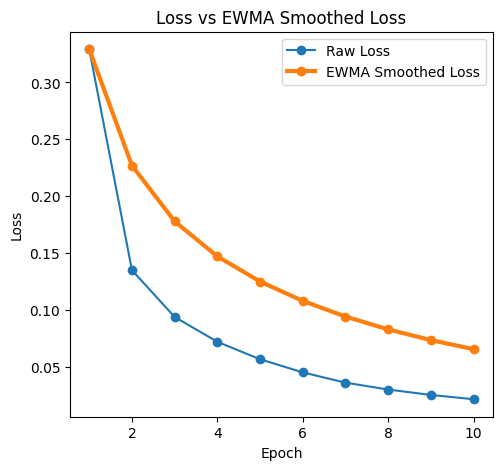

In [9]:
# STEP 7: VISUALIZE RESULTS
# ---------------------------------------------------

epochs = range(1, len(ewma_callback.raw_losses) + 1)

# ---------------------------------------------------
# LOSS GRAPH
# ---------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    epochs,
    ewma_callback.raw_losses,
    marker='o',
    label='Raw Loss'
)

plt.plot(
    epochs,
    ewma_callback.ewma_losses,
    marker='o',
    linewidth=3,
    label='EWMA Smoothed Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs EWMA Smoothed Loss")
plt.legend()


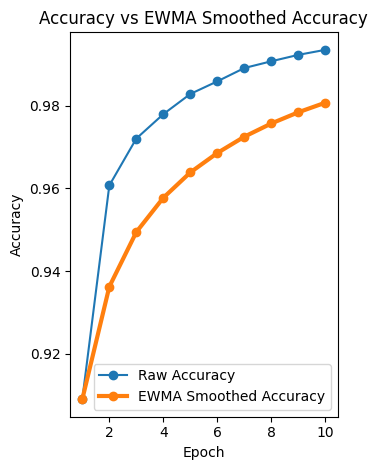

In [10]:





# ACCURACY GRAPH
# ---------------------------------------------------

plt.subplot(1, 2, 2)

plt.plot(
    epochs,
    ewma_callback.raw_accuracies,
    marker='o',
    label='Raw Accuracy'
)

plt.plot(
    epochs,
    ewma_callback.ewma_accuracies,
    marker='o',
    linewidth=3,
    label='EWMA Smoothed Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs EWMA Smoothed Accuracy")
plt.legend()

plt.tight_layout()
plt.show()